In [5]:
"""
SSH numerical framework for periodic chain
Author: Zeynepnur Sahinel
Purpose:
    Numerical implementation of the SSH model and computation of
    band structure, correlation matrices, and entanglement measures.
"""

'\nSSH numerical framework for periodic chain\nAuthor: Zeynepnur Sahinel\nPurpose:\n    Numerical implementation of the SSH model and computation of\n    band structure, correlation matrices, and entanglement measures.\n'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# ============================================================
# SSH: common utilities
# ============================================================

def ssh_couplings(lam: float) -> tuple[float, float]:
    """t1 = 1 + lam,  t2 = 1 - lam"""
    return 1.0 + lam, 1.0 - lam

def ssh_dispersion_from_t1t2(k: np.ndarray, t1, t2) -> np.ndarray:
    """|h(k)| = sqrt(t1^2 + t2^2 + 2 t1 t2 cos k)"""
    return np.sqrt(t1**2 + t2**2 + 2.0*t1*t2*np.cos(k))

def ssh_energy_pm(k: np.ndarray, lam: float) -> tuple[np.ndarray, np.ndarray]:
    """E_-(k), E_+(k) using lam parametrization."""
    t1, t2 = ssh_couplings(lam)
    Ep = ssh_dispersion_from_t1t2(k, t1, t2)
    return -Ep, Ep

def make_figure_ssh_bands(
    lams_line=(-0.8, -0.4, 0.0, 0.4, 0.8),
    lam_range=(-1.0, 1.0),
    nk=400,
    nlam=400,
    cmap="inferno",
    savepath=None,
    show=True,
):
    if savepath is None:
        savepath = f"{FIG_DIR}/fig_1_ssh_bands.pdf"

    k = np.linspace(0.0, 2.0*np.pi, nk)
    lam_grid = np.linspace(lam_range[0], lam_range[1], nlam)
    K, L = np.meshgrid(k, lam_grid)

    t1 = 1.0 + L
    t2 = 1.0 - L
    E2D = ssh_dispersion_from_t1t2(K, t1, t2)

    fig, axes = plt.subplots(2, 1, figsize=(8, 10), constrained_layout=True)

    # Panel A
    ax1 = axes[0]
    for lam in lams_line:
        Em, Ep = ssh_energy_pm(k, lam)
        (line,) = ax1.plot(k, Ep, label=rf"$\lambda={lam}$")
        ax1.plot(k, Em, color=line.get_color())

    ax1.set_xlabel(r"$k$")
    ax1.set_ylabel("Energy")
    ax1.set_title(r"SSH band structure for different $\lambda$")
    ax1.legend()

    xticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])

    # Panel B
    ax2 = axes[1]
    pcm = ax2.pcolormesh(K, L, E2D, shading="auto", cmap=cmap)
    ax2.set_xlabel(r"$k$")
    ax2.set_ylabel(r"$\lambda$")
    ax2.set_title(r"Upper SSH energy band $E_+(k,\lambda)$")
    ax2.set_xticks(xticks)
    ax2.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    fig.colorbar(pcm, ax=ax2, label="Energy")

    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, axes

def fermi_dirac(E: np.ndarray, beta: float) -> np.ndarray:
    """Fermi–Dirac distribution: n(E) = 1/(exp(beta E)+1)."""
    return 1.0 / (np.exp(beta * E) + 1.0)

def make_figure_band_occupation(
    lam: float = 0.0,          # default critical point (t1=t2)
    beta: float = 2.0,
    nk: int = 400,
    savepath: str | None = None,
    show: bool = True,
):
    """
    Creates the 2-panel occupation figure:
      (top)  n_+(k)
      (bottom) n_-(k)

    Uses the same SSH parametrization t1=1+lam, t2=1-lam
    to stay consistent with the rest of the codebase.
    """
    if savepath is None:
        savepath = f"{FIG_DIR}/fig_2_band_occupation.pdf"

    # k grid
    k = np.linspace(0.0, 2.0*np.pi, nk)

    # energies from same common dispersion
    t1, t2 = ssh_couplings(lam)
    h_abs = ssh_dispersion_from_t1t2(k, t1, t2)
    E_plus = h_abs
    E_minus = -h_abs

    # occupations
    n_plus = fermi_dirac(E_plus, beta)
    n_minus = fermi_dirac(E_minus, beta)

    # plot
    fig, axs = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

    axs[0].plot(k, n_plus)
    axs[0].set_ylabel(r"$n_+(k)$")
    axs[0].set_title(rf"Upper band occupation ($\beta={beta},\, \lambda={lam}$)")

    axs[1].plot(k, n_minus)
    axs[1].set_ylabel(r"$n_-(k)$")
    axs[1].set_title(rf"Lower band occupation ($\beta={beta},\, \lambda={lam}$)")
    axs[1].set_xlabel(r"$k$")

    # π ticks
    axs[1].set_xticks([0, np.pi, 2*np.pi])
    axs[1].set_xticklabels([r"$0$", r"$\pi$", r"$2\pi$"])

    plt.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, axs

def make_figure_upper_occupation_overlay(
    lam: float = 0.0,
    betas=(30, 5, 2, 1, 0.5),
    nk: int = 400,
    savepath: str | None = None,
    show: bool = True,
):
    """
    Single-panel overlay of n_+(k) for multiple betas at fixed lambda.
    Uses n_+(k) = 1/(exp(beta E_+(k))+1), with E_+(k)=|h(k)|.
    """
    if savepath is None:
        savepath = f"{FIG_DIR}/fig_occ_overlay_lam{lam}.pdf"

    k = np.linspace(0.0, 2.0*np.pi, nk)

    t1, t2 = ssh_couplings(lam)
    E_plus = ssh_dispersion_from_t1t2(k, t1, t2)

    fig, ax = plt.subplots(1, 1, figsize=(6.5, 3.8))

    for beta in betas:
        n_plus = fermi_dirac(E_plus, beta)
        ax.plot(k, n_plus, label=rf"$\beta={beta}$")

    ax.set_xlabel(r"$k$")
    ax.set_ylabel(r"$n_+(k)$")
    ax.set_title(rf"Upper band occupation $n_+(k)$ (fixed $\lambda={lam}$)")

    ax.set_xticks([0, np.pi, 2*np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi$", r"$2\pi$"])
    ax.set_ylim(-0.02, 0.52)  # çünkü n_+ ∈ [0, 1/2] (mu=0 simetri)

    ax.legend(ncol=2, fontsize=9)
    plt.tight_layout()

    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax


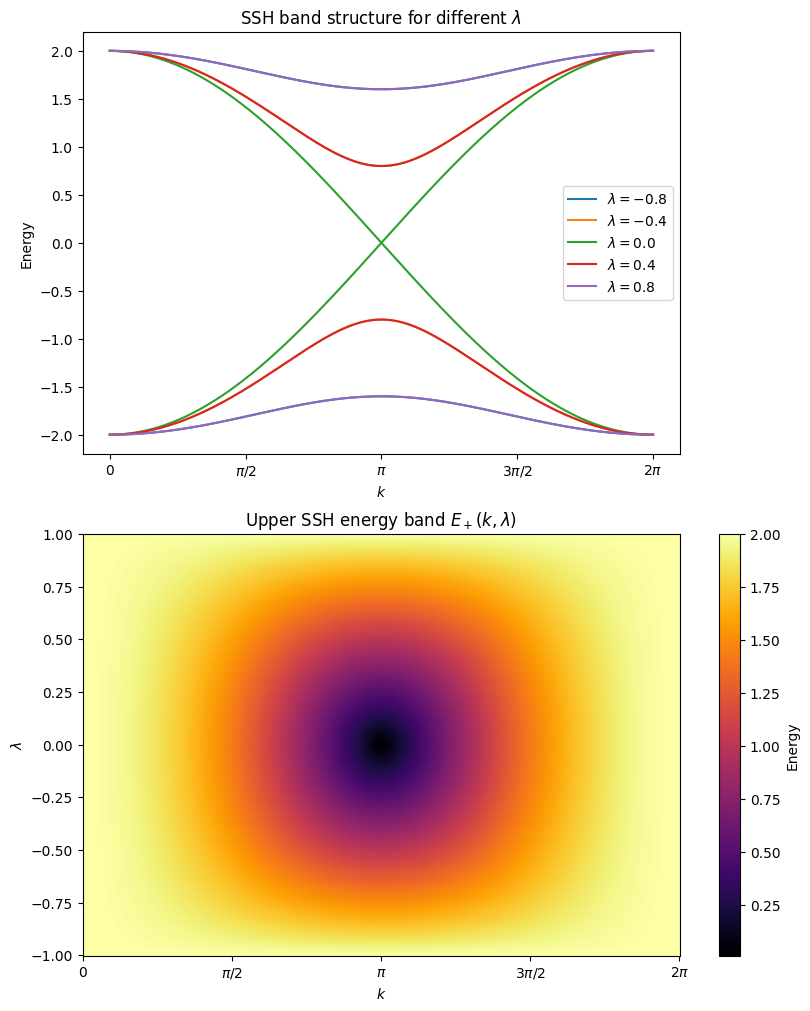

(<Figure size 800x1000 with 3 Axes>,
 array([<Axes: title={'center': 'SSH band structure for different $\\lambda$'}, xlabel='$k$', ylabel='Energy'>,
        <Axes: title={'center': 'Upper SSH energy band $E_+(k,\\lambda)$'}, xlabel='$k$', ylabel='$\\lambda$'>],
       dtype=object))

In [3]:
#Energy band diagrams for the SSH model
#(a)Upper energy band E+(k) for selected lambdas
#(b)Upper energy band E+(k, lambda) heatmap
make_figure_ssh_bands()

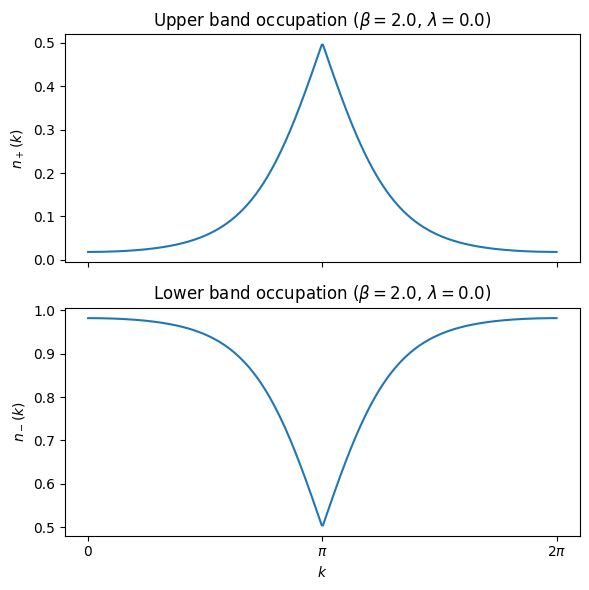

(<Figure size 600x600 with 2 Axes>,
 array([<Axes: title={'center': 'Upper band occupation ($\\beta=2.0,\\, \\lambda=0.0$)'}, ylabel='$n_+(k)$'>,
        <Axes: title={'center': 'Lower band occupation ($\\beta=2.0,\\, \\lambda=0.0$)'}, xlabel='$k$', ylabel='$n_-(k)$'>],
       dtype=object))

In [6]:
make_figure_band_occupation(lam=0.0, beta=2.0)  # fig_2_band_occupation.pdf

In [7]:
make_figure_upper_occupation_overlay(lam=0.0, betas=(30, 5, 2, 1, 0.5))

NameError: name 'make_figure_upper_occupation_overlay' is not defined